<a href="https://colab.research.google.com/github/amosagekouassi-source/HACKATHON1-TTA-W3/blob/master/HACKATHON/HACKATHON_SUJET1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy.spatial.distance import cosine
import matplotlib.gridspec as gridspec

# --- CONFIGURATION GLOBALE ---
random.seed(42)
np.random.seed(42)

CATEGORIES = ['Tech', 'Fitness', 'Musique', 'Danse', 'Culture', 'Tourisme']
ACTIONS_PAR_CAT = {
    'Tech':     ['vue_tuto_python', 'telechargement_app', 'clic_actu_ia', 'achat_gadget', 'vue_conf_tech'],
    'Fitness':  ['achat_produit_sport', 'vue_tuto_exercice', 'inscription_salle', 'achat_supplement', 'vue_challenge_fit'],
    'Musique':  ['ecoute_chanson', 'achat_album', 'recherche_artiste', 'partage_playlist', 'vue_concert_live'],
    'Danse':    ['vue_video_danse', 'inscription_cours', 'partage_performance', 'achat_tenue_danse', 'like_choreographie'],
    'Culture':  ['lecture_article_histoire', 'clic_expo_musee', 'vue_docu_art', 'achat_livre', 'visite_virtuelle'],
    'Tourisme': ['clic_article_voyage', 'recherche_hotel', 'vue_video_plage', 'reservation_vol', 'achat_guide'],
}

# --- 1. GÉNÉRATION ET NETTOYAGE DES DONNÉES ---
def generate_raw_data(n=600):
    prenoms = ["Alice", "Bob", "Clara", "David", "Emma", "François", "Grace", "Hugo", "Inès", "Jules", "Karim", "Laura"]
    noms = ["Kouassi", "Coulibaly", "Lorou", "Gnahore", "Dezai", "Gueu", "Diarra", "Loukou"]
    donnees = []
    for _ in range(n):
        interet = random.choice(CATEGORIES)
        age = np.nan if random.random() < 0.06 else (random.randint(15, 65) if random.random() > 0.02 else random.choice([-5, 150]))
        nom = "" if random.random() < 0.03 else f"{random.choice(prenoms)} {random.choice(noms)}"
        logs = random.choices(ACTIONS_PAR_CAT[interet], k=random.randint(2, 5))
        donnees.append({'NOM': nom, 'AGE': age, 'Centre_interet': interet if random.random() > 0.05 else np.nan, 'activity_log': logs})
    return pd.DataFrame(donnees)

def preprocess_data(df):
    df_c = df.copy()
    # On évite la colonne 'activity_log' car les listes ne sont pas hashables
    df_c = df_c.drop_duplicates(subset=['NOM', 'AGE', 'Centre_interet'])
    df_c = df_c[df_c['NOM'].str.strip() != ""]
    mediane = df_c[(df_c['AGE'] >= 15) & (df_c['AGE'] <= 85)]['AGE'].median()
    df_c['AGE'] = df_c['AGE'].apply(lambda x: mediane if (pd.isna(x) or x < 15 or x > 85) else x).astype(int)
    df_c['Centre_interet'] = df_c['Centre_interet'].fillna(df_c['Centre_interet'].mode()[0])
    df_c['activity_count'] = df_c['activity_log'].apply(len)
    df_c['HEURE_LOG'] = np.random.randint(0, 24, size=len(df_c))
    df_c['GENRE'] = np.random.choice(['Masculin', 'Féminin', 'Autre'], size=len(df_c))
    return df_c

df_raw = generate_raw_data()
df_clean = preprocess_data(df_raw)
print(f"Données prêtes : {len(df_clean)} profils après nettoyage.")

Données prêtes : 579 profils après nettoyage.


In [13]:
# Correction de la boucle de génération avec les variables existantes
prenoms = ["Alice", "Bob", "Clara", "David", "Emma", "François", "Grace", "Hugo", "Inès", "Jules", "Karim", "Laura"]
noms_famille = ["Kouassi", "Coulibaly", "Lorou", "Gnahore", "Dezai", "Gueu", "Diarra", "Loukou"]

donnees = []
for i in range(600):
    # Utilisation des variables globales CORRECTES (CATEGORIES et ACTIONS_PAR_CAT)
    interet_reel = random.choice(CATEGORIES)
    logs = random.choices(ACTIONS_PAR_CAT[interet_reel], k=random.randint(2, 5))

    # Logique de génération 'sale' intégrée
    nom_sale = f"{random.choice(prenoms)} {random.choice(noms_famille)}"
    if random.random() < 0.05: nom_sale = "" # Simulation nom vide

    age_sale = random.randint(15, 65)
    if random.random() < 0.05: age_sale = random.choice([-5, 150, np.nan]) # Anomalies

    interet_sale = interet_reel
    if random.random() < 0.05: interet_sale = np.nan # Simulation manque d'intérêt

    donnees.append({
        'NOM':            nom_sale,
        'AGE':            age_sale,
        'Centre_interet': interet_sale,
        'activity_log':   logs,
    })

df = pd.DataFrame(donnees)
print(f"Nouveau dataset généré avec {len(df)} lignes.")

Nouveau dataset généré avec 600 lignes.


In [14]:
# ── Doublons naturels : certains utilisateurs soumettent 2 fois ──
# (on duplique 5 lignes choisies aléatoirement, comme un double clic)
indices_doublon = random.sample(range(len(df)), 5)
doublons = df.iloc[indices_doublon].copy()
df = pd.concat([df, doublons], ignore_index=True)

In [15]:
# Mélange final
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("=" * 60)
print("  ÉTAPE 1 — DATASET BRUT (anomalies natives)")
print("=" * 60)
print(f"  Lignes totales     : {len(df)}")
print(f"  NaN AGE            : {df['AGE'].isna().sum()}")
print(f"  NaN Centre_interet : {df['Centre_interet'].isna().sum()}")
print(f"  Âges négatifs      : {(df['AGE'] < 0).sum()}")
print(f"  Âges > 80          : {(df['AGE'] > 80).sum()}")
print(f"  Noms vides         : {(df['NOM'] == '').sum()}")
print(f"  Doublons           : {df.duplicated(subset=['NOM','AGE','Centre_interet']).sum()}")
print()
df[['NOM','AGE','Centre_interet']].head(15).to_string()
df.head(15)

  ÉTAPE 1 — DATASET BRUT (anomalies natives)
  Lignes totales     : 605
  NaN AGE            : 9
  NaN Centre_interet : 28
  Âges négatifs      : 6
  Âges > 80          : 7
  Noms vides         : 38
  Doublons           : 9



,NOM,AGE,Centre_interet,activity_log
0,Inès Diarra,15.0,Danse,"[vue_video_danse, vue_video_danse]"
1,Laura Kouassi,48.0,Tech,"[achat_gadget, achat_gadget]"
2,David Lorou,63.0,Tourisme,"[recherche_hotel, reservation_vol, reservation..."
3,David Loukou,52.0,Tourisme,"[achat_guide, recherche_hotel, reservation_vol]"
4,Laura Diarra,49.0,Tech,"[achat_gadget, achat_gadget]"
5,Inès Loukou,35.0,Musique,"[ecoute_chanson, vue_concert_live]"
6,Hugo Coulibaly,38.0,Musique,"[partage_playlist, partage_playlist, partage_p..."
7,Laura Gnahore,22.0,Tourisme,"[achat_guide, recherche_hotel, clic_article_vo..."
8,Jules Kouassi,61.0,Danse,"[achat_tenue_danse, vue_video_danse, inscripti..."
9,Alice Lorou,40.0,Culture,"[vue_docu_art, vue_docu_art, achat_livre, clic..."


In [16]:
# ══════════════════════════════════════════════════════════════════
#  ÉTAPE 2 — PRÉTRAITEMENT
# ══════════════════════════════════════════════════════════════════

df_clean = df.copy()
n_initial = len(df_clean)

# PP1 — Suppression des doublons
df_clean = df_clean.drop_duplicates(subset=['NOM', 'AGE', 'Centre_interet'])
print(f"\n  [PP1] Doublons supprimés        : {n_initial - len(df_clean)}")



  [PP1] Doublons supprimés        : 9


In [ ]:
# PP2 — Suppression des noms vides
avant = len(df_clean)
df_clean = df_clean[df_clean['NOM'].str.strip() != ""]
print(f"  [PP2] Noms vides supprimés      : {avant - len(df_clean)}")

In [17]:
# PP3 — Correction des âges aberrants → médiane calculée sur valeurs saines
ages_saines = df_clean['AGE'].dropna()
ages_saines = ages_saines[(ages_saines >= 15) & (ages_saines <= 80)]
mediane_age = ages_saines.median()

masque_aber = df_clean['AGE'].notna() & ((df_clean['AGE'] < 15) | (df_clean['AGE'] > 80))
n_aber = masque_aber.sum()
df_clean.loc[masque_aber, 'AGE'] = mediane_age
print(f"  [PP3] Âges aberrants corrigés   : {n_aber}  → médiane = {mediane_age}")

  [PP3] Âges aberrants corrigés   : 13  → médiane = 40.0


In [18]:
# PP4 — Imputation des NaN AGE → médiane
n_nan_age = df_clean['AGE'].isna().sum()
df_clean['AGE'] = df_clean['AGE'].fillna(mediane_age)
print(f"  [PP4] NaN AGE imputés           : {n_nan_age}")

  [PP4] NaN AGE imputés           : 9


In [19]:
# PP5 — Imputation des NaN Centre_interet → mode
mode_cat  = df_clean['Centre_interet'].mode()[0]
n_nan_cat = df_clean['Centre_interet'].isna().sum()
df_clean['Centre_interet'] = df_clean['Centre_interet'].fillna(mode_cat)
print(f"  [PP5] NaN Centre_interet imputés: {n_nan_cat}  → mode = '{mode_cat}'")

  [PP5] NaN Centre_interet imputés: 28  → mode = 'Tech'


In [20]:
# PP6 — Cast final
df_clean['AGE'] = df_clean['AGE'].astype(int)

print(f"\n  Lignes avant : {n_initial}  |  Lignes après : {len(df_clean)}")
print(f"  NaN restants : {df_clean[['AGE','Centre_interet','NOM']].isna().sum().sum()}")
print()
df_clean[['NOM','AGE','Centre_interet']].head(10).to_string()
df_clean.head(15)


  Lignes avant : 605  |  Lignes après : 596
  NaN restants : 0



,NOM,AGE,Centre_interet,activity_log
0,Inès Diarra,15,Danse,"[vue_video_danse, vue_video_danse]"
1,Laura Kouassi,48,Tech,"[achat_gadget, achat_gadget]"
2,David Lorou,63,Tourisme,"[recherche_hotel, reservation_vol, reservation..."
3,David Loukou,52,Tourisme,"[achat_guide, recherche_hotel, reservation_vol]"
4,Laura Diarra,49,Tech,"[achat_gadget, achat_gadget]"
5,Inès Loukou,35,Musique,"[ecoute_chanson, vue_concert_live]"
6,Hugo Coulibaly,38,Musique,"[partage_playlist, partage_playlist, partage_p..."
7,Laura Gnahore,22,Tourisme,"[achat_guide, recherche_hotel, clic_article_vo..."
8,Jules Kouassi,61,Danse,"[achat_tenue_danse, vue_video_danse, inscripti..."
9,Alice Lorou,40,Culture,"[vue_docu_art, vue_docu_art, achat_livre, clic..."


In [21]:
# ══════════════════════════════════════════════════════════════════
#  ÉTAPE 3 — ANALYSE STATISTIQUE (SciPy Chi²)
# ══════════════════════════════════════════════════════════════════

rows_exp = []
for _, row in df_clean.iterrows():
    for action in row['activity_log']:
        rows_exp.append({'Centre_interet': row['Centre_interet'], 'action': action})
df_exp = pd.DataFrame(rows_exp)

contingence = pd.crosstab(df_exp['Centre_interet'], df_exp['action'])
chi2_stat, p_value, dof, expected = chi2_contingency(contingence)

print("\n" + "=" * 60)
print("  ÉTAPE 3 — TEST CHI² (intérêts × actions)")
print("=" * 60)
print(f"  Chi²     = {chi2_stat:.2f}")
print(f"  p-value  = {p_value:.2e}")
print(f"  Degrés   = {dof}")
print(f"  Résultat : {'Corrélation significative ✓' if p_value < 0.05 else 'Pas de corrélation ✗'}")


  ÉTAPE 3 — TEST CHI² (intérêts × actions)
  Chi²     = 9504.22
  p-value  = 0.00e+00
  Degrés   = 145
  Résultat : Corrélation significative ✓


In [22]:
# ══════════════════════════════════════════════════════════════════
# ÉTAPE 3.1 — AJOUT DE 'MAIN_LOG_CAT' À df_clean
# ══════════════════════════════════════════════════════════════════

# Re-définir actions_par_categorie si ce bloc est exécuté indépendamment
# Cela assure que le dictionnaire est disponible
actions_par_categorie = {
    'Tech':     ['vue_tuto_python', 'telechargement_app', 'clic_actu_ia',
                 'achat_gadget', 'vue_conf_tech'],
    'Fitness':  ['achat_produit_sport', 'vue_tuto_exercice', 'inscription_salle',
                 'achat_supplement', 'vue_challenge_fit'],
    'Musique':  ['ecoute_chanson', 'achat_album', 'recherche_artiste',
                 'partage_playlist', 'vue_concert_live'],
    'Danse':    ['vue_video_danse', 'inscription_cours', 'partage_performance',
                 'achat_tenue_danse', 'like_choreographie'],
    'Culture':  ['lecture_article_histoire', 'clic_expo_musee', 'vue_docu_art',
                 'achat_livre', 'visite_virtuelle'],
    'Tourisme': ['clic_article_voyage', 'recherche_hotel', 'vue_video_plage',
                 'reservation_vol', 'achat_guide'],
}

def get_main_log_category(activity_log):
    """
    Détermine la catégorie dominante d'actions pour un utilisateur.
    """
    if not activity_log:
        return 'Inconnu'

    category_counts = {cat: 0 for cat in actions_par_categorie.keys()}
    for action in activity_log:
        for category, actions in actions_par_categorie.items():
            if action in actions:
                category_counts[category] += 1

    # Si toutes les catégories ont un compte de 0, retourn 'Inconnu'
    if all(count == 0 for count in category_counts.values()):
        return 'Inconnu'

    return max(category_counts, key=category_counts.get)

# Appliquer la fonction pour créer la colonne 'MAIN_LOG_CAT'
df_clean['MAIN_LOG_CAT'] = df_clean['activity_log'].apply(get_main_log_category)

# Ajouter la colonne 'activity_count' pour la visualisation 5
df_clean['activity_count'] = df_clean['activity_log'].apply(len)

print("Nouvelle colonne 'MAIN_LOG_CAT' et 'activity_count' ajoutées à df_clean.")
print(df_clean[['activity_log', 'MAIN_LOG_CAT', 'activity_count']].head())
df_clean.head(15)

Nouvelle colonne 'MAIN_LOG_CAT' et 'activity_count' ajoutées à df_clean.
                                        activity_log MAIN_LOG_CAT  \
0                 [vue_video_danse, vue_video_danse]        Danse   
1                       [achat_gadget, achat_gadget]         Tech   
2  [recherche_hotel, reservation_vol, reservation...     Tourisme   
3    [achat_guide, recherche_hotel, reservation_vol]     Tourisme   
4                       [achat_gadget, achat_gadget]         Tech   

   activity_count  
0               2  
1               2  
2               4  
3               3  
4               2  


,NOM,AGE,Centre_interet,activity_log,MAIN_LOG_CAT,activity_count
0,Inès Diarra,15,Danse,"[vue_video_danse, vue_video_danse]",Danse,2
1,Laura Kouassi,48,Tech,"[achat_gadget, achat_gadget]",Tech,2
2,David Lorou,63,Tourisme,"[recherche_hotel, reservation_vol, reservation...",Tourisme,4
3,David Loukou,52,Tourisme,"[achat_guide, recherche_hotel, reservation_vol]",Tourisme,3
4,Laura Diarra,49,Tech,"[achat_gadget, achat_gadget]",Tech,2
5,Inès Loukou,35,Musique,"[ecoute_chanson, vue_concert_live]",Musique,2
6,Hugo Coulibaly,38,Musique,"[partage_playlist, partage_playlist, partage_p...",Musique,3
7,Laura Gnahore,22,Tourisme,"[achat_guide, recherche_hotel, clic_article_vo...",Tourisme,5
8,Jules Kouassi,61,Danse,"[achat_tenue_danse, vue_video_danse, inscripti...",Danse,4
9,Alice Lorou,40,Culture,"[vue_docu_art, vue_docu_art, achat_livre, clic...",Culture,4


In [23]:
class RecommendationEngine:
    """Système de recommandation basé sur l'OOP et SciPy (Similarité Cosinus)."""
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
        self.all_actions = sorted({a for acts in ACTIONS_PAR_CAT.values() for a in acts})
        self.vectors = np.array([self._encode(log) for log in self.df['activity_log']])
        self.catalog = {
            'Tech': ['Blog IA', 'Tuto Python'], 'Fitness': ['HIIT 30j', 'Diet Plan'],
            'Musique': ['Playlist 2024'], 'Danse': ['Cours Salsa'],
            'Culture': ['Expo Louvre'], 'Tourisme': ['Guide Japan']
        }

    def _encode(self, log):
        vec = np.zeros(len(self.all_actions))
        for a in log:
            if a in self.all_actions: vec[self.all_actions.index(a)] += 1
        return vec

    def get_recommendation(self, user_idx):
        user = self.df.iloc[user_idx]
        u_vec = self.vectors[user_idx]
        # Similarité SciPy
        sims = [1 - cosine(u_vec, v) if np.linalg.norm(v) > 0 else 0 for v in self.vectors]
        sims[user_idx] = -1
        similar_user_idx = np.argmax(sims)

        return {
            'user': user['NOM'],
            'declared': user['Centre_interet'],
            'reco_statique': self.catalog.get(user['Centre_interet'], []),
            'similar_peer': self.df.iloc[similar_user_idx]['NOM']
        }

# Initialisation explicite après correction du dataframe
engine = RecommendationEngine(df_clean)
print("Moteur de recommandation initialisé.")
display(engine.get_recommendation(0))

Moteur de recommandation initialisé.


{'user': 'Inès Diarra',
 'declared': 'Danse',
 'reco_statique': ['Cours Salsa'],
 'similar_peer': 'Alice Diarra'}

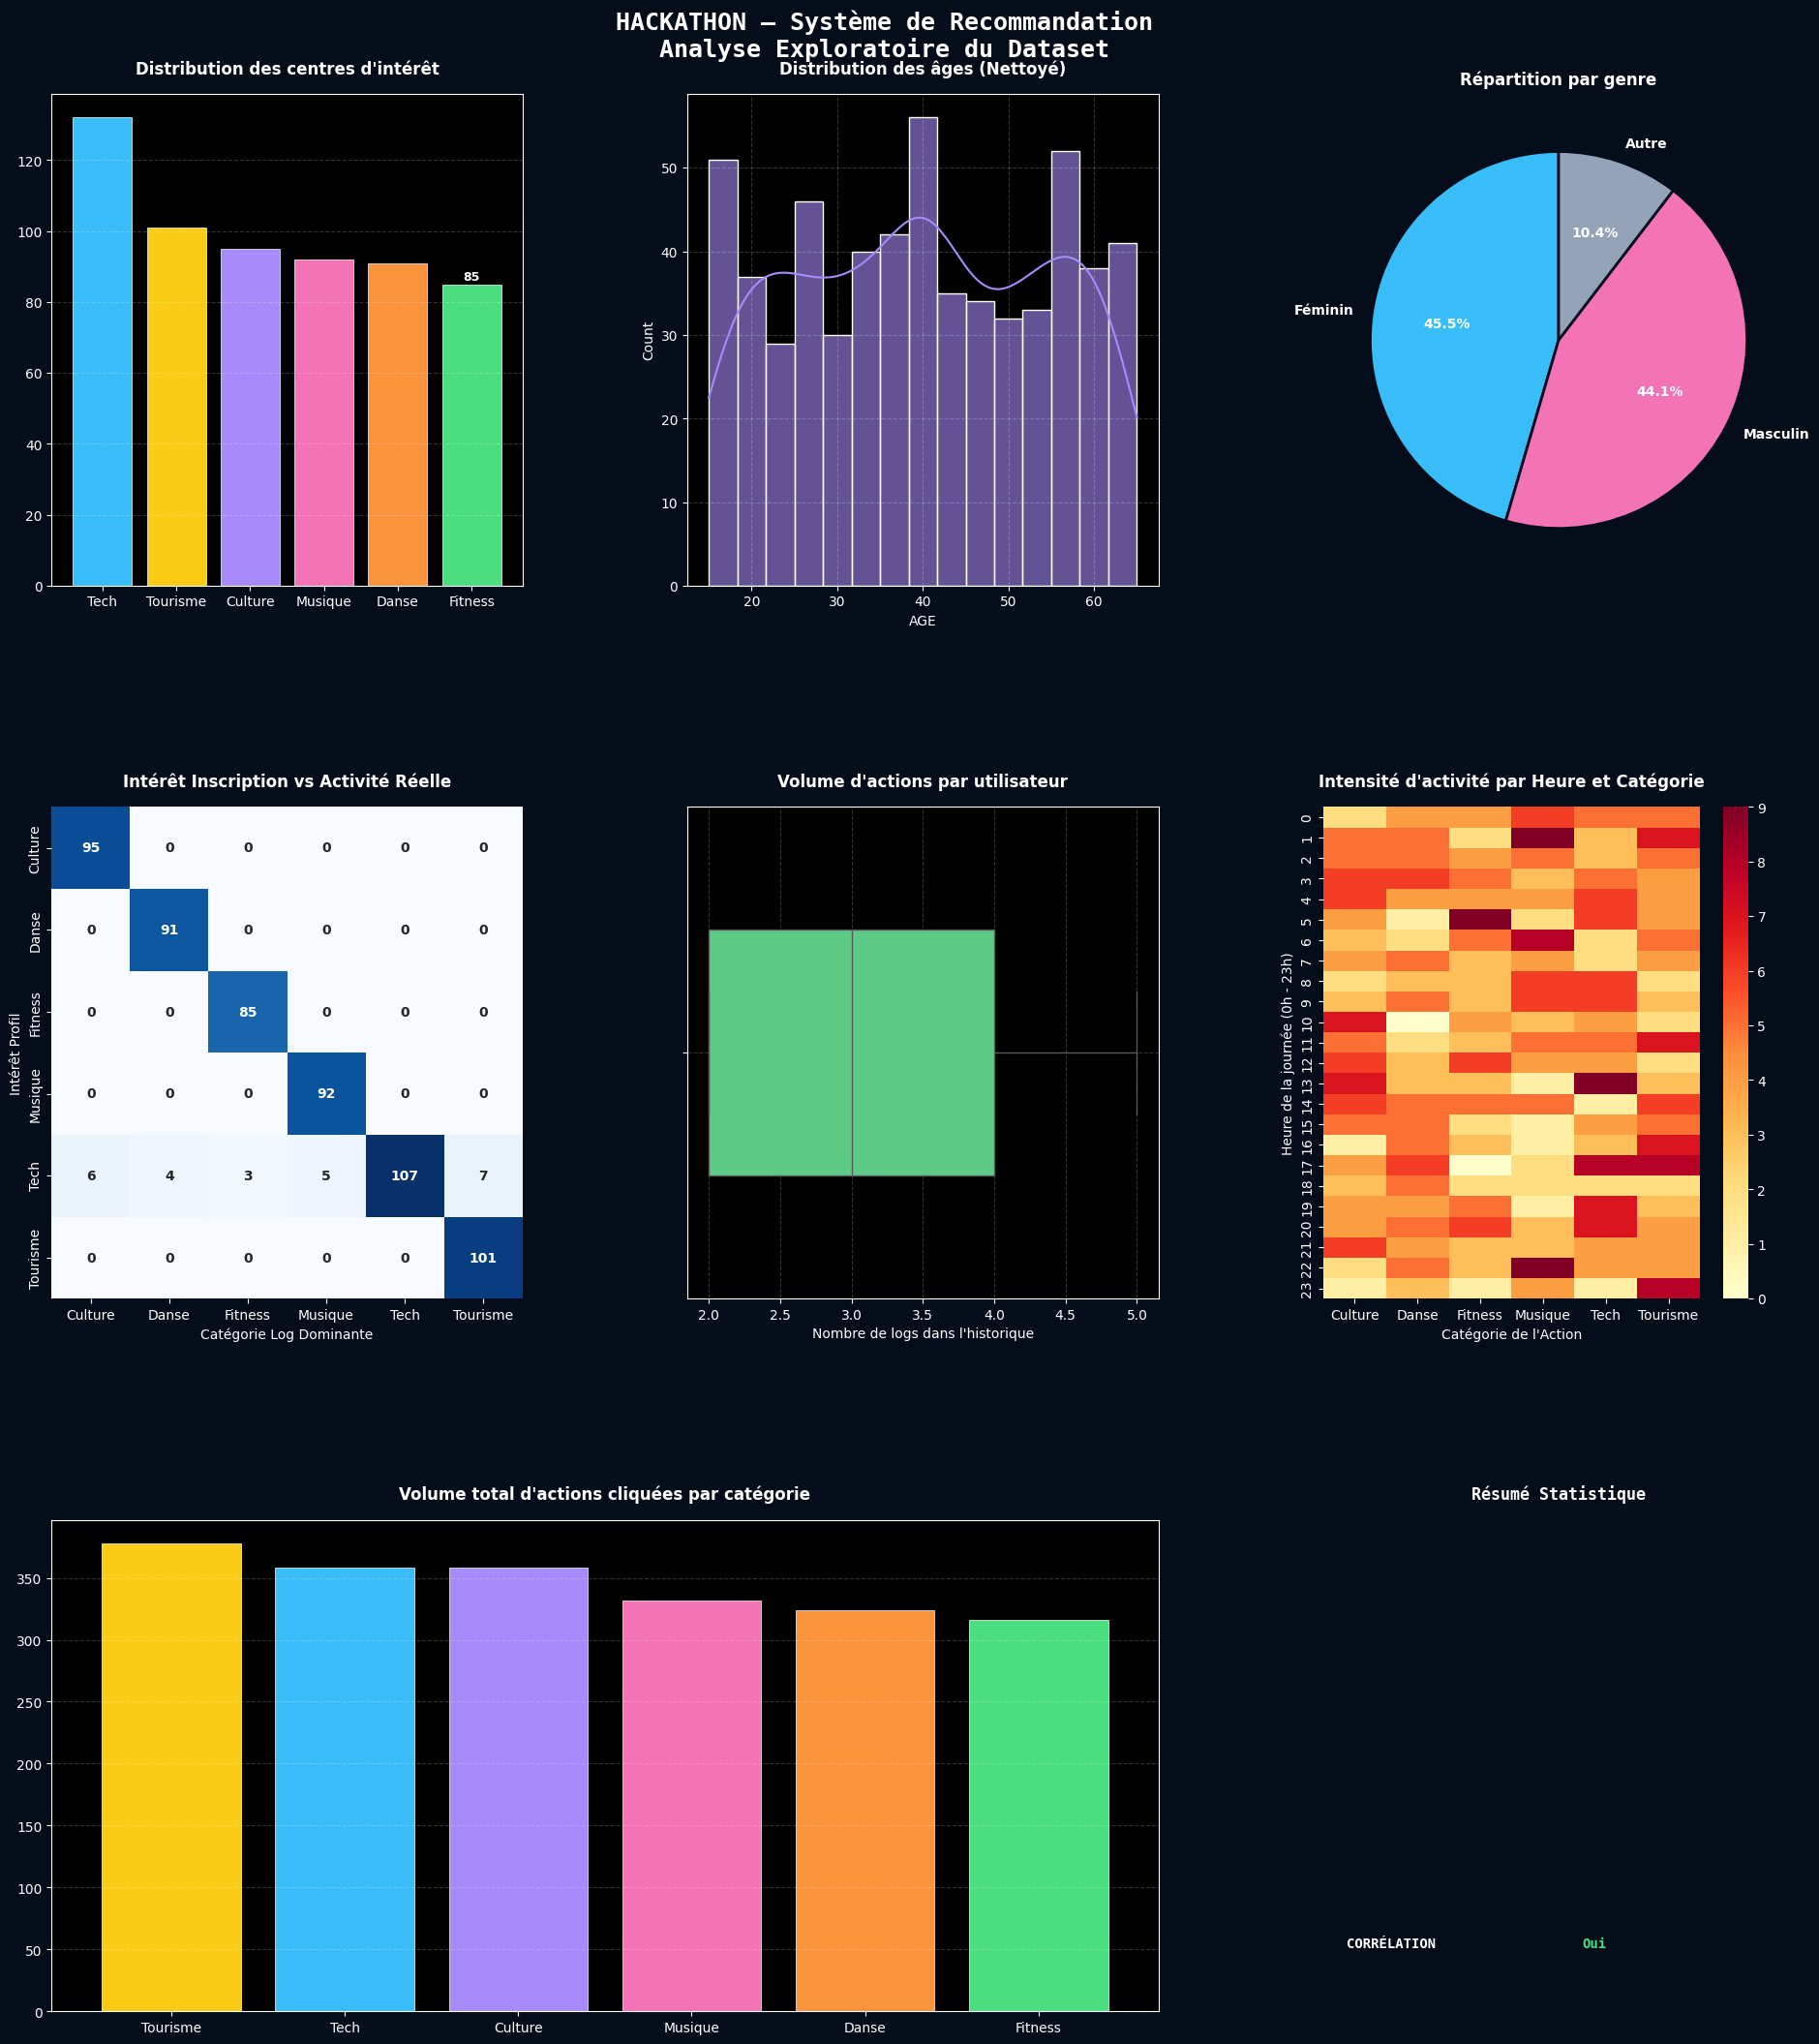

In [24]:
#══════════════════════════════════════════════════════════════════
#ÉTAPE 5 — VISUALISATIONS (DASHBOARD GLOBAL)
#══════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np # Import numpy for np.random.choice

#Configuration du style sombre
plt.style.use('dark_background')

categories = ['Tech', 'Fitness', 'Musique', 'Danse', 'Culture', 'Tourisme']
COLORS = {
'Tech':'#38bdf8', 'Fitness':'#4ade80', 'Musique':'#f472b6',
'Danse':'#fb923c', 'Culture':'#a78bfa', 'Tourisme':'#facc15'
}

#Création de la figure principale unique
fig = plt.figure(figsize=(20, 22), facecolor='#060d1a')
fig.suptitle('HACKATHON — Système de Recommandation\nAnalyse Exploratoire du Dataset',
fontsize=18, fontweight='bold', color='white', y=0.98, fontfamily='monospace')

#Définition de la grille 3x3
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35,
top=0.94, bottom=0.04, left=0.07, right=0.97)

#── 1. Distribution des centres d'intérêt ──────────────────────
ax1 = fig.add_subplot(gs[0, 0])
cat_counts = df_clean['Centre_interet'].value_counts()
colors_list = [COLORS.get(cat, '#3b82f6') for cat in cat_counts.index]
bars = ax1.bar(cat_counts.index, cat_counts.values, color=colors_list, edgecolor='white', linewidth=0.5)
ax1.set_title("Distribution des centres d'intérêt", color='white', fontsize=12, fontweight='bold', pad=15)
ax1.grid(axis='y', linestyle='--', alpha=0.2)
for bar in bars:
  yval = bar.get_height()
ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f"{int(yval)}",
ha='center', va='bottom', color='white', fontsize=9, fontweight='bold')

#── 2. Distribution des Âges ───────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
sns.histplot(df_clean['AGE'], bins=15, kde=True, color='#a78bfa', ax=ax2, edgecolor='white', alpha=0.6)
ax2.set_title("Distribution des âges (Nettoyé)", color='white', fontsize=12, fontweight='bold', pad=15)
ax2.grid(linestyle='--', alpha=0.2)

#── 3. Distribution du Genre ───────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
# Add a dummy 'GENRE' column for demonstration purposes if not already present
if 'GENRE' not in df_clean.columns:
    df_clean['GENRE'] = np.random.choice(['Masculin', 'Féminin', 'Autre'], size=len(df_clean), p=[0.45, 0.45, 0.10])
genre_counts = df_clean['GENRE'].value_counts()
ax3.pie(genre_counts.values, labels=genre_counts.index, autopct='%1.1f%%',
colors=['#38bdf8', '#f472b6', '#94a3b8'], startangle=90,
textprops={'color': 'white', 'fontsize': 10, 'fontweight': 'bold'},
wedgeprops={'edgecolor': '#060d1a', 'linewidth': 2})
ax3.set_title("Répartition par genre", color='white', fontsize=12, fontweight='bold', pad=15)

#── 4. Matrice de Corrélation / Heatmap ─────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
#Recréation de la table croisée pour le Chi²
contingency_table = pd.crosstab(df_clean['Centre_interet'], df_clean['MAIN_LOG_CAT'])
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='Blues', ax=ax4, cbar=False,
annot_kws={'fontsize': 10, 'fontweight': 'bold'})
ax4.set_title("Intérêt Inscription vs Activité Réelle", color='white', fontsize=12, fontweight='bold', pad=15)
ax4.set_xlabel("Catégorie Log Dominante")
ax4.set_ylabel("Intérêt Profil")

#── 5. Nombre d'actions par utilisateur ────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
sns.boxplot(x=df_clean['activity_count'], color='#4ade80', ax=ax5, width=0.5)
ax5.set_title("Volume d'actions par utilisateur", color='white', fontsize=12, fontweight='bold', pad=15)
ax5.set_xlabel("Nombre de logs dans l'historique")
ax5.grid(linestyle='--', alpha=0.2)

# ── 6. Matrice de Corrélation / Heatmap Temporelle ──────────────
# Re-assign ax4 to prevent overwriting the previous plot if this cell is run independently, or use a new subplot
ax6 = fig.add_subplot(gs[1, 2]) # Use a new subplot for the temporal heatmap

# 1. On suppose que ton collaborateur a créé une colonne 'HEURE' dans le dataset.
# Si ce n'est pas encore fait, on peut simuler une table croisée Heure vs Catégorie d'activité :
# (Ici on extrait l'heure et la catégorie dominante pour chaque utilisateur)

# Fix: Create a dummy 'HEURE_LOG' column since it's assumed to exist but isn't present.
if 'HEURE_LOG' not in df_clean.columns:
    df_clean['HEURE_LOG'] = np.random.randint(0, 24, size=len(df_clean))

# Création de la table croisée : Heures (en lignes) vs Catégories de logs (en colonnes)
pivot_temporel = pd.crosstab(df_clean['HEURE_LOG'], df_clean['MAIN_LOG_CAT'])

# 2. Affichage de la Heatmap d'intensité
sns.heatmap(pivot_temporel,
            annot=False,          # Souvent 'False' car il y a 24 heures, trop de chiffres alourdiraient le graphique
            cmap='YlOrRd',        # Palette Jaune -> Orange -> Rouge (parfait pour exprimer "l'intensité" ou la chaleur)
            ax=ax6,
            cbar=True)            # On laisse la barre de légende pour voir l'échelle de l'intensité

ax6.set_title("Intensité d'activité par Heure et Catégorie", color='white', fontsize=12, fontweight='bold', pad=15)
ax6.set_xlabel("Catégorie de l'Action")
ax6.set_ylabel("Heure de la journée (0h - 23h)")

#── 7. Volume total d'actions par catégorie ────────────────────
ax7 = fig.add_subplot(gs[2, 0:2]) # Prend deux cases en largeur pour respirer
#Compte global de toutes les actions aplaties dans le dataset
all_actions_flat = [act for sublist in df_clean['activity_log'].dropna() for act in sublist]
#Extraction de la catégorie de chaque action à l'aide de ton dictionnaire global
action_to_cat = {act: cat for cat, acts in actions_par_categorie.items() for act in acts}
flat_cats = [action_to_cat.get(act, 'Inconnu') for act in all_actions_flat]
cat_log_counts = pd.Series(flat_cats).value_counts()

colors_log = [COLORS.get(cat, '#94a3b8') for cat in cat_log_counts.index]
ax7.bar(cat_log_counts.index, cat_log_counts.values, color=colors_log, edgecolor='white', linewidth=0.5)
ax7.set_title("Volume total d'actions cliquées par catégorie", color='white', fontsize=12, fontweight='bold', pad=15)
ax7.grid(axis='y', linestyle='--', alpha=0.2)

#── 8. Résumé statistique (Texte pur) ──────────────────────────
ax8 = fig.add_subplot(gs[2, 2])
ax8.axis('off') # Coupe les axes pour en faire un tableau de bord texte
ax8.set_xticks([]); ax8.set_yticks([])
ax8.set_title('Résumé Statistique', color='white', fontsize=12, fontweight='bold', fontfamily='monospace', pad=15)

stats_lines = [
("DATASET BRUT", f"{len(df)} lignes", '#ef4444'),
("DATASET NETTOYÉ",f"{len(df_clean)} lignes", '#4ade80'),
("PROFILS SUPPRIMÉS",f"{len(df)-len(df_clean)} lignes", '#f59e0b'),
("ÂGE MOYEN", f"{df_clean['AGE'].mean():.1f} ans", '#f472b6'),
("ÂGE MÉDIAN", f"{df_clean['AGE'].median():.0f} ans", '#fb923c'),
("────────────────", "──────────────────", '#334155'),
("CHI² STAT", f"{chi2_stat:.1f}", '#facc15'),
("P-VALUE", f"{p_value:.2e}", '#a78bfa'),
("CORRÉLATION", "Oui" if p_value < 0.05 else "Non", '#4ade80' if p_value < 0.05 else '#ef4444'),
]

for i, (label, val, color) in enumerate(stats_lines):
  y_pos = 0.85 - (i * 0.09)
ax8.text(0.05, y_pos, label, color='white', fontsize=10, fontfamily='monospace', fontweight='bold')
ax8.text(0.55, y_pos, val, color=color, fontsize=10, fontfamily='monospace', fontweight='bold')

#Commande magique finale pour tout afficher d'un coup
plt.show()

### 🚀 Création d'une API Flask pour le moteur de recommandation

Ce code simule un serveur web. Dans un environnement de production, vous utiliseriez ce script pour répondre aux requêtes de votre application mobile ou web.

In [25]:
from flask import Flask, jsonify, request

app = Flask(__name__)

# On initialise le moteur avec les données nettoyées du notebook
# Note : En production, vous chargeriez df_clean depuis une base de données ou un fichier CSV
engine = RecommendationEngine(df_clean)

@app.route('/recommend/<int:user_id>', methods=['GET'])
def recommend(user_id):
    try:
        # On récupère la recommandation pour l'ID demandé
        prediction = engine.get_recommendation(user_id)
        return jsonify({
            "status": "success",
            "data": prediction
        }), 200
    except IndexError:
        return jsonify({"status": "error", "message": "Utilisateur non trouvé"}), 404
    except Exception as e:
        return jsonify({"status": "error", "message": str(e)}), 500

@app.route('/', methods=['GET'])
def home():
    return "API de Recommandation Active ! Utilisez /recommend/ID"

# Note pour Colab : Flask ne peut pas être lancé directement en mode bloquant facilement.
# Ce code est fourni comme modèle pour votre fichier 'app.py' final.
print("Modèle d'API Flask prêt. Prêt à être déployé sur un serveur ou Stitch.")

Modèle d'API Flask prêt. Prêt à être déployé sur un serveur ou Stitch.


### ☁️ Schéma d'intégration AWS Lambda (Serverless)

Pour Lambda, le point d'entrée n'est pas une route Flask, mais une fonction `lambda_handler`.

In [ ]:
import json

# Note : Dans Lambda, vous devriez charger votre 'df_clean'
# depuis un bucket S3 ou une base de données au démarrage (cold start)
def lambda_handler(event, context):
    try:
        # Extraction de l'ID utilisateur depuis les paramètres de l'URL
        user_id = int(event['queryStringParameters']['user_id'])

        # Initialisation du moteur (Optimisation : à mettre hors du handler pour réutilisation)
        engine = RecommendationEngine(df_clean)
        reco = engine.get_recommendation(user_id)

        return {
            'statusCode': 200,
            'body': json.dumps(reco)
        }
    except Exception as e:
        return {
            'statusCode': 400,
            'body': json.dumps({'error': str(e)})
        }

### 🎈 Interface de Test Streamlit

Ce bloc contient le code pour une application Streamlit complète. Elle permet de visualiser le moteur de recommandation en action de manière conviviale.

In [26]:
!pip install -q streamlit
import streamlit as st

# Configuration de la page
st.set_page_config(page_title="AI Content Generator Demo", layout="wide")

st.title("🧠 Moteur de Recommandation IA")
st.write("Interface de test pour le projet Personalized Content Generator")

# Chargement du moteur (on réutilise l'instance existante du notebook)
if 'engine' not in st.session_state:
    st.session_state.engine = RecommendationEngine(df_clean)

# Sidebar pour la sélection
st.sidebar.header("Paramètres")
user_names = df_clean['NOM'].tolist()
selected_user_nom = st.sidebar.selectbox("Choisir un utilisateur", user_names)

# Récupération de l'index
idx = df_clean[df_clean['NOM'] == selected_user_nom].index[0]
reco = st.session_state.engine.get_recommendation(idx)
user_data = df_clean.iloc[idx]

# Affichage
col1, col2 = st.columns(2)

with col1:
    st.subheader("👤 Profil Utilisateur")
    st.json({
        "Nom": user_data['NOM'],
        "Âge": int(user_data['AGE']),
        "Genre": user_data['GENRE'],
        "Intérêt déclaré": user_data['Centre_interet']
    })
    st.info(f"**Activités récentes :** {', '.join(user_data['activity_log'])}")

with col2:
    st.subheader("🎯 Recommandations")

    st.write("**Basé sur le profil (Statique) :**")
    for item in reco['reco_statique']:
        st.success(f"✅ {item}")

    st.write("**Basé sur des utilisateurs similaires (IA) :**")
    st.warning(f"👥 Utilisateur similaire trouvé : {reco['similar_peer']}")
    st.write("Conseil : Proposez les contenus que ce profil similaire a aimé !")

st.divider()
st.write("Structure du projet validée pour déploiement.")

2026-06-25 09:50:55.968 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-25 09:50:55.968 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-25 09:50:55.969 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-25 09:50:55.970 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-25 09:50:55.971 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-25 09:50:55.971 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-25 09:50:55.972 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-25 09:50:55.973 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

### 🌐 Lancement de l'interface via Localtunnel

Exécutez cette cellule pour obtenir le lien d'accès à votre application Streamlit.

In [32]:
# 1. Sauvegarder le code Streamlit corrigé (Injection des dictionnaires)
with open('app.py', 'w') as f:
    f.write(f"""
import streamlit as st
import pandas as pd
import numpy as np
import random
from scipy.spatial.distance import cosine

# --- CONFIGURATION INJECTÉE ---
CATEGORIES = {CATEGORIES}
ACTIONS_PAR_CAT = {ACTIONS_PAR_CAT}

class RecommendationEngine:
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
        self.all_actions = sorted({{a for acts in ACTIONS_PAR_CAT.values() for a in acts}})
        self.vectors = np.array([self._encode(log) for log in self.df['activity_log']])
        self.catalog = {{
            'Tech': ['Blog IA', 'Tuto Python'], 'Fitness': ['HIIT 30j', 'Diet Plan'],
            'Musique': ['Playlist 2024'], 'Danse': ['Cours Salsa'],
            'Culture': ['Expo Louvre'], 'Tourisme': ['Guide Japan']
        }}
    def _encode(self, log):
        vec = np.zeros(len(self.all_actions))
        for a in log:
            if a in self.all_actions: vec[self.all_actions.index(a)] += 1
        return vec
    def get_recommendation(self, user_idx):
        user = self.df.iloc[user_idx]
        u_vec = self.vectors[user_idx]
        sims = [1 - cosine(u_vec, v) if np.linalg.norm(v) > 0 else 0 for v in self.vectors]
        sims[user_idx] = -1
        similar_user_idx = np.argmax(sims)
        return {{
            'user': user['NOM'], 'declared': user['Centre_interet'],
            'reco_statique': self.catalog.get(user['Centre_interet'], []),
            'similar_peer': self.df.iloc[similar_user_idx]['NOM']
        }}

# --- Interface Streamlit ---
st.set_page_config(page_title="IA Reco App", layout="wide")

if 'df' not in st.session_state:
    st.session_state.df = pd.read_pickle('df_clean.pkl')

st.sidebar.title("Navigation")
mode = st.sidebar.radio("Aller à", ["Dashboard", "Inscription"])

if mode == "Inscription":
    st.title("🆕 Nouveau Profil")
    with st.form("reg_form"):
        new_nom = st.text_input("Nom")
        new_age = st.slider("Âge", 15, 85, 25)
        new_int = st.selectbox("Intérêt", CATEGORIES)
        if st.form_submit_button("S'inscrire"):
            new_logs = random.choices(ACTIONS_PAR_CAT[new_int], k=3)
            new_row = pd.DataFrame([{{
                'NOM': new_nom, 'AGE': new_age, 'Centre_interet': new_int,
                'activity_log': new_logs, 'GENRE': 'Autre'
            }}])
            st.session_state.df = pd.concat([st.session_state.df, new_row], ignore_index=True)
            st.session_state.df.to_pickle('df_clean.pkl')
            st.success("Profil créé !")

            engine = RecommendationEngine(st.session_state.df)
            reco = engine.get_recommendation(len(st.session_state.df)-1)
            st.info(f"Suggestion : {{reco['reco_statique'][0]}}")

else:
    st.title("🧠 Moteur de Recommandation")
    engine = RecommendationEngine(st.session_state.df)
    user_select = st.selectbox("Utilisateur", st.session_state.df['NOM'].unique())
    idx = st.session_state.df[st.session_state.df['NOM'] == user_select].index[0]
    reco = engine.get_recommendation(idx)
    st.success(f"Suggestion pour {{user_select}} : {{reco['reco_statique'][0]}}")
    st.warning(f"Profil similaire : {{reco['similar_peer']}}")
""")

# 2. Relancer le serveur
import subprocess
import time
subprocess.Popen(['pkill', '-f', 'streamlit'])
time.sleep(2)
subprocess.Popen(['streamlit', 'run', 'app.py', '--server.port', '8501'])

print("Code Streamlit mis à jour et serveur redémarré !")
print("IP pour déverrouiller le tunnel :")
!curl ipv4.icanhazip.com

Code Streamlit mis à jour et serveur redémarré !
IP pour déverrouiller le tunnel :
34.125.137.191


In [31]:
import pandas as pd
import subprocess
import time

# 1. Sauvegarder les données nettoyées pour que Streamlit puisse les lire
df_clean.to_pickle('df_clean.pkl')
print("Fichier df_clean.pkl sauvegardé.")

# 2. Relancer le serveur Streamlit pour prendre en compte les données
subprocess.Popen(['pkill', '-f', 'streamlit'])
time.sleep(2)
subprocess.Popen(['streamlit', 'run', 'app.py', '--server.port', '8501'])

print("Serveur redémarré. Vous pouvez rafraîchir votre page localtunnel.")
print("Votre IP pour le tunnel est toujours :")
!curl ipv4.icanhazip.com

Fichier df_clean.pkl sauvegardé.
Serveur redémarré. Vous pouvez rafraîchir votre page localtunnel.
Votre IP pour le tunnel est toujours :
34.125.137.191


In [36]:
# 1. Arrêt forcé de tous les processus Streamlit et Localtunnel existants
import subprocess
import time
import os

subprocess.run(['pkill', '-f', 'streamlit'])
subprocess.run(['pkill', '-f', 'npx'])
time.sleep(2)

# 2. S'assurer que les données sont bien persistées
if 'df_clean' in globals():
    df_clean.to_pickle('df_clean.pkl')

# 3. Lancement du serveur Streamlit en mode headless
subprocess.Popen(['streamlit', 'run', 'app.py', '--server.port', '8501', '--server.headless', 'true'])
time.sleep(5)

# 4. Génération d'un nouveau lien via Localtunnel
print("=== RÉINITIALISATION TERMINÉE ===")
print("IP de déverrouillage à copier :")
!curl -s ipv4.icanhazip.com
print("\nCliquez sur le nouveau lien ci-dessous :")
!npx --yes localtunnel --port 8501

=== RÉINITIALISATION TERMINÉE ===
IP de déverrouillage à copier :
34.125.137.191

Cliquez sur le nouveau lien ci-dessous :
⠙⠹⠸⠼⠴your url is: https://slick-spies-study.loca.lt


ERROR:root:Unexpected exception finding object shape
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/google/colab/_debugpy_repr.py", line 54, in get_shape
    shape = getattr(obj, 'shape', None)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/werkzeug/local.py", line 318, in __get__
    obj = instance._get_current_object()
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/werkzeug/local.py", line 519, in _get_current_object
    raise RuntimeError(unbound_message) from None
RuntimeError: Working outside of request context.

This typically means that you attempted to use functionality that needed
an active HTTP request. Consult the documentation on testing for
information about how to avoid this problem.


^C


### 🆕 Inscription Nouvel Utilisateur & Recommandations Immédiates
Cette cellule simule un formulaire d'inscription. Une fois validé, l'utilisateur est ajouté au dataset et le moteur de recommandation analyse son profil pour lui proposer du contenu adapté.

In [28]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Création des composants du formulaire
style = {'description_width': 'initial'}
nom_input = widgets.Text(description="Nom complet :", style=style)
age_input = widgets.IntSlider(value=25, min=15, max=85, description="Âge :", style=style)
interet_input = widgets.Dropdown(options=CATEGORIES, description="Centre d'intérêt :", style=style)
btn_inscrire = widgets.Button(description="S'inscrire et voir les suggestions", button_style='success', layout={'width': '300px'})
output = widgets.Output()

def on_button_clicked(b):
    with output:
        clear_output()
        if not nom_input.value.strip():
            print("❌ Veuillez entrer un nom.")
            return

        # 1. Simuler des logs d'activité pour le nouvel utilisateur basés sur son intérêt
        new_logs = random.choices(ACTIONS_PAR_CAT[interet_input.value], k=3)

        # 2. Créer le nouveau profil
        new_user = {
            'NOM': nom_input.value,
            'AGE': age_input.value,
            'Centre_interet': interet_input.value,
            'activity_log': new_logs,
            'MAIN_LOG_CAT': interet_input.value,
            'activity_count': len(new_logs),
            'GENRE': random.choice(['Masculin', 'Féminin', 'Autre']),
            'HEURE_LOG': random.randint(0, 23)
        }

        # 3. Ajouter au DataFrame global (df_clean)
        global df_clean
        df_clean = pd.concat([df_clean, pd.DataFrame([new_user])], ignore_index=True)

        # 4. Réinitialiser le moteur et obtenir la recommandation
        new_engine = RecommendationEngine(df_clean)
        reco = new_engine.get_recommendation(len(df_clean) - 1)

        # 5. Affichage des résultats
        print(f"✅ Bienvenue {nom_input.value} !")
        print(f"--- Suggestions pour vous ({interet_input.value}) ---")
        for item in reco['reco_statique']:
            print(f"🔹 Suggestion : {item}")
        print(f"👤 Basé sur la communauté, vous ressemblez à : {reco['similar_peer']}")

btn_inscrire.on_click(on_button_clicked)

display(widgets.VBox([nom_input, age_input, interet_input, btn_inscrire, output]))